# GZD-5 Classfication
___

## Setup

### Importing Packages

In [2]:
%matplotlib widget

import os
import shutil
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from scipy.optimize import curve_fit 
from astronomaly.dimensionality_reduction import pca
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from umap import UMAP
from projectFunctions import myBGMM, myMBKM, create_gz_evaluation_set, saving_images, distance_bin_plots, confidence_bin_plots

### Directories

In [3]:
# Data Root Directory
data_root_dir = os.path.join(os.getcwd(), 'Data')

# Image Directory
img_dir = os.path.join(data_root_dir, 'Images')

# Label Directory
label_dir = os.path.join(data_root_dir, 'gz_decals_volunteers_5.parquet')

# Feature Directory
feature_dir = os.path.join(data_root_dir, 'GalaxyZoo_Main_Features.parquet')

### Feature Space

#### Loading Feature Data

In [4]:
features = pd.read_parquet(feature_dir)
print('Features: ', features.shape)

Features:  (230575, 512)


#### PCA

In [5]:
my_pca = pca.PCA_Decomposer(force_rerun=True, n_components=29, threshold=0.95, output_dir=data_root_dir)
pca_features = my_pca.run(features)
pca_features.to_parquet(os.path.join(data_root_dir, 'pca_features.parquet'))
print('PCA Features: ', pca_features.shape)
print(type(pca_features))

Running PCA_Decomposer ...
Total explained variance: 0.9516112676479792
Done! Time taken: 1.100724220275879 s
PCA Features:  (230575, 29)
<class 'pandas.core.frame.DataFrame'>


### Volunteer Labels

#### Loading Label Data

In [6]:
full_volunteer_labels = pd.read_parquet(label_dir)
full_volunteer_labels = full_volunteer_labels.set_index('iauname')
print('Full GZD-5 Volunteer Labels: ', full_volunteer_labels.shape)
full_volunteer_labels = full_volunteer_labels[~full_volunteer_labels['wrong_size_warning']]
print('wrong_size_warning filtered GZD-5 Volunteer Labels: ', full_volunteer_labels.shape)
print('columns: ', full_volunteer_labels.columns)

Full GZD-5 Volunteer Labels:  (253286, 126)
wrong_size_warning filtered GZD-5 Volunteer Labels:  (250930, 126)
columns:  Index(['ra', 'dec', 'redshift', 'elpetro_absmag_r', 'sersic_nmgy_r',
       'petro_th50', 'petro_th90', 'petro_theta', 'upload_group',
       'active_learning_on',
       ...
       'merging_minor-disturbance_fraction',
       'merging_minor-disturbance_debiased', 'merging_major-disturbance',
       'merging_major-disturbance_fraction',
       'merging_major-disturbance_debiased', 'merging_merger',
       'merging_merger_fraction', 'merging_merger_debiased',
       'wrong_size_statistic', 'wrong_size_warning'],
      dtype='object', length=126)


#### Refining Volunteer Labels

In [7]:
my_label_df, summ = create_gz_evaluation_set(full_volunteer_labels, 
                                             question_level=3, min_votes=34, max_votes=None, half_votes_min=True, min_prob=0, max_prob=1, min_sources=100)
print('Refined GZD-5 Evaluation Set: ', my_label_df.shape)

Refined GZD-5 Evaluation Set:  (47153, 5)


#### Confidently Labeled [Elliptical, Spiral, Edge On]

Labelled Galaxies:  (24858, 127)
Round Ellipticals:  9464
Spirals:  12432
Edge-ons:  2962


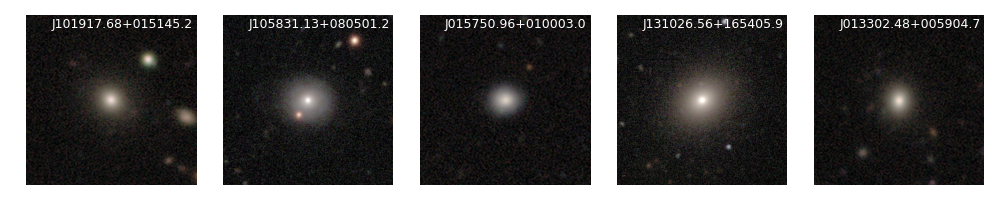

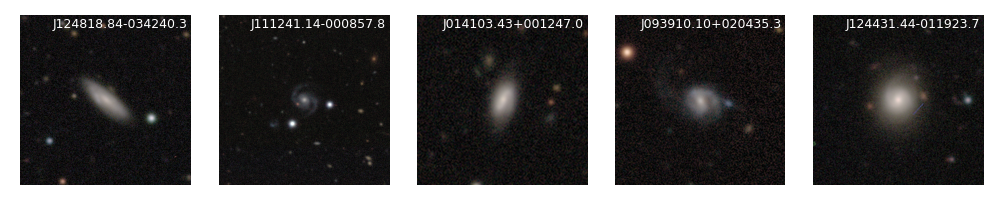

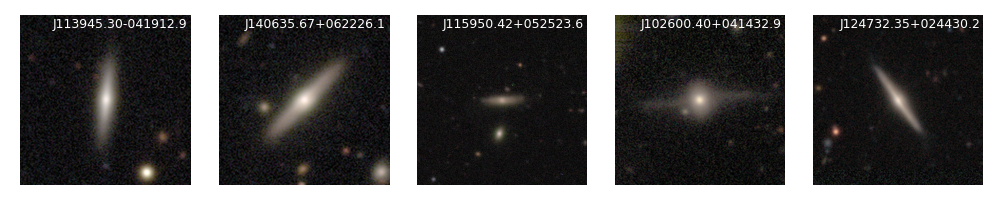

In [8]:
ellipticals = my_label_df[(my_label_df['smooth-or-featured'] == 'smooth-or-featured_smooth') & 
                          (my_label_df['merging'] == 'merging_none') & 
                          (my_label_df['how-rounded'] == 'how-rounded_round')].index
spirals = my_label_df[(my_label_df['smooth-or-featured'] == 'smooth-or-featured_featured-or-disk') & 
                      (my_label_df['merging'] == 'merging_none') &
                      (my_label_df['disk-edge-on'] == 'disk-edge-on_no')].index
edge_ons = my_label_df[(my_label_df['smooth-or-featured'] == 'smooth-or-featured_featured-or-disk') & 
                       (my_label_df['merging'] == 'merging_none') &
                       (my_label_df['disk-edge-on'] == 'disk-edge-on_yes')].index

saving_images(ellipticals, 'elliptical', img_dir, data_root_dir)
saving_images(spirals, 'spiral', img_dir, data_root_dir)
saving_images(edge_ons, 'edge_on', img_dir, data_root_dir)

# Combining the indices of the three classes to create a single DataFrame of volunteer labels
volunteer_labels_indices = ellipticals.union(spirals).union(edge_ons)
# Filtering the full volunteer labels to only include the galaxies that belong to the three classes
volunteer_labels = full_volunteer_labels.loc[volunteer_labels_indices]
# Assigning class labels to the volunteer labels DataFrame
volunteer_labels.loc[ellipticals, 'Volunteer_Label'] = 'R'   # Round ellipticals
volunteer_labels.loc[spirals, 'Volunteer_Label'] = 'S'       # Spirals
volunteer_labels.loc[edge_ons, 'Volunteer_Label'] = 'E'      # Edge-ons

print('Labelled Galaxies: ', volunteer_labels.shape)
print('Round Ellipticals: ',    (volunteer_labels['Volunteer_Label'] == 'R').sum())
print('Spirals: ',              (volunteer_labels['Volunteer_Label'] == 'S').sum())
print('Edge-ons: ',             (volunteer_labels['Volunteer_Label'] == 'E').sum())

## Clustering

In [9]:
method = 'MBKM'
no_of_runs = 5
low_member_threshold = 300
low_percentage_threshold = 50

no_of_clusters_to_test = np.arange(3,41,1)
#no_of_clusters_to_test = np.array([20])

In [15]:
results = []
rng = np.random.default_rng(42)
metric_sample = rng.choice(len(pca_features), size=10000, replace=False)

for no_of_clusters in no_of_clusters_to_test:
    print(f"No. of Clusters: {no_of_clusters}")
    for i in range(no_of_runs):

        if method == 'MBKM':
            mbkm_inertia, silhouette, david, clusters = myMBKM(pca_features, n_clusters=no_of_clusters, max_iter=10, n_init=10, metric_sample=metric_sample)
            prefix = 'Distance'
        elif method == 'BGMM':
            bgmm_weights, bgmm_lower_bound, silhouette, david, clusters = myBGMM(pca_features, n_components=no_of_clusters, weight_concentration_prior=0.5, 
                                                                                 n_init=10, max_iter=1000, metric_sample=metric_sample)
            prefix = 'Prob'
        #print(f'{method} Clusters: ', clusters.shape)

        distance_cols = [f"{prefix}_{i}" for i in range(no_of_clusters)]
        distance_array = clusters[distance_cols].to_numpy()
        # Finding Assigned Distance by selecting the distance corresponding to the assigned cluster for each row
        clusters[f'Assigned_{prefix}'] = distance_array[np.arange(len(clusters)), clusters['Cluster'].to_numpy()]
        
        # PREDICTING FROM MODAL TEST SUBSET
        ####################################
        # Merging the cluster assignments with the confident labels
        test_subset = clusters.merge(volunteer_labels, left_index=True, right_index=True, how='inner')
        test_subset.to_parquet(os.path.join(data_root_dir, f'{method}_test_subset.parquet'))

        #print('Labelled and Clustered Galaxies: ', test_subset.shape)
        #print('Round Ellipticals: ',    (test_subset['Volunteer_Label'] == 'R').sum())
        #print('Spirals: ',              (test_subset['Volunteer_Label'] == 'S').sum())
        #print('Edge-ons: ',             (test_subset['Volunteer_Label'] == 'E').sum())

        # Group by Cluster and Type to find how many of each type in each cluster
        counts = test_subset.groupby(['Cluster', 'Volunteer_Label']).size()
        counts_df = counts.reset_index(name='Count')
        # Add Total and Percentage Accuracy Columns
        counts_df['Total'] = counts_df.groupby('Cluster')['Count'].transform('sum')
        counts_df['Percentage'] = counts_df['Count'] / counts_df['Total'] * 100
        low_member_clusters = counts_df[counts_df['Total'] < low_member_threshold]['Cluster'].unique()
        #print(f"Clusters with less than {low_member_threshold} members: {low_member_clusters}")
        #print(counts_df)

        # Find Dominant Type in Each Cluster
        dominant = counts_df.loc[counts_df.groupby('Cluster')['Count'].idxmax()]
        # Save Summary Array
        summary_df = dominant.set_index('Cluster')[['Volunteer_Label', 'Percentage']]
        summary_df.columns = ['Dominant_Type', 'Percentage']
        low_percentage_clusters = (summary_df[summary_df['Percentage'] < low_percentage_threshold].index).to_numpy()
        #print(f"Clusters with less than {low_percentage_threshold}% dominant type: {low_percentage_clusters}")
        #print(summary_df)

        # Map the dominant type to each galaxy based on its cluster assignment
        clusters["Dominant_Type"] = clusters["Cluster"].map(summary_df["Dominant_Type"])
        test_subset['Predicted_Label'] = test_subset['Cluster'].map(summary_df['Dominant_Type'])

        # EVALUATION METRICS
        ######################
        accuracy = accuracy_score(test_subset['Volunteer_Label'], test_subset['Predicted_Label'])
        print(f'Run {i + 1}')
        if method == 'MBKM':
            results.append({"n_clusters": no_of_clusters,
                            "run": i + 1,
                            "accuracy": accuracy,
                            "inertia": mbkm_inertia,
                            "silhouette": silhouette,
                            "david_bouldin": david})
        elif method == 'BGMM':
            results.append({"n_clusters": no_of_clusters,
                            "run": i + 1,
                            "accuracy": accuracy,
                            "weights": bgmm_weights,
                            "silhouette": silhouette,
                            "lower_bound": bgmm_lower_bound,
                            "david_bouldin": david})
        #R_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'R']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'R']['Predicted_Label']) 
        #S_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'S']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'S']['Predicted_Label']) 
        #E_accuracy = accuracy_score(test_subset[test_subset['Volunteer_Label'] == 'E']['Volunteer_Label'], test_subset[test_subset['Volunteer_Label'] == 'E']['Predicted_Label']) 
        
        #print(f'Overall Accuracy: {accuracy:.2f}')
        #print('Class Accuracy\n##############')
        #print(f'R: {R_accuracy:.2f}')
        #print(f'S: {S_accuracy:.2f}')
        #print(f'E: {E_accuracy:.2f}')
        #print('\nClassification Report\n#####################')
        #print(classification_report(test_subset['Volunteer_Label'], test_subset['Predicted_Label'], labels=['R', 'S', 'E']))

results = pd.DataFrame(results)
print(results)
results.to_parquet(os.path.join(data_root_dir, f'{method}_results.parquet'))

No. of Clusters: 3
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 4
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 5
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 6
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 7
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 8
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 9
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 10
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 11
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 12
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 13
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 14
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 15
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 16
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 17
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 18
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 19
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 20
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 21
Run 1
Run 2
Run 3
Run 4
Run 5
No. of Clusters: 22
Run 1
Run 2
Run 3
Run 4
Run 5
No. of 

## Number of Clusters Analysis

### BGMM Weights

In [ ]:
print('Low Membership Clusters (<300): ',low_member_clusters)
print('Low Accuracy Clusters (<50%): ',low_percentage_clusters)

plt.close('all')
weights = results['weights'].iat[0]
x_val = np.arange(len(weights))

plt.figure(figsize=(8, 6))
plt.scatter(x_val, weights)

for x, y in zip(x_val, weights):
    plt.annotate(
        f'{x}',
        (x, y),
        xytext=(5, 5),
        textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8)
    )

plt.xlim(0, len(weights) + 1)
plt.grid(True)
plt.xlabel('Cluster')
plt.ylabel('Weight')
plt.show()

### No. of clusters vs Avg. Accuracy 

    n_clusters      mean       std  count       sem
0            3  0.576541  0.030975      5  0.013852
1            4  0.587647  0.044130      5  0.019736
2            5  0.587596  0.067584      5  0.030225
3            6  0.627797  0.070017      5  0.031313
4            7  0.578347  0.063496      5  0.028396
5            8  0.644984  0.045559      5  0.020375
6            9  0.662362  0.053701      5  0.024016
7           10  0.691737  0.033265      5  0.014877
8           11  0.694778  0.018908      5  0.008456
9           12  0.721468  0.033182      5  0.014839
10          13  0.716876  0.012572      5  0.005622
11          14  0.720272  0.020443      5  0.009142
12          15  0.714547  0.023837      5  0.010660
13          16  0.724178  0.012072      5  0.005399
14          17  0.726277  0.033454      5  0.014961
15          18  0.732905  0.026910      5  0.012035
16          19  0.743261  0.011352      5  0.005077
17          20  0.753018  0.027069      5  0.012106
18          

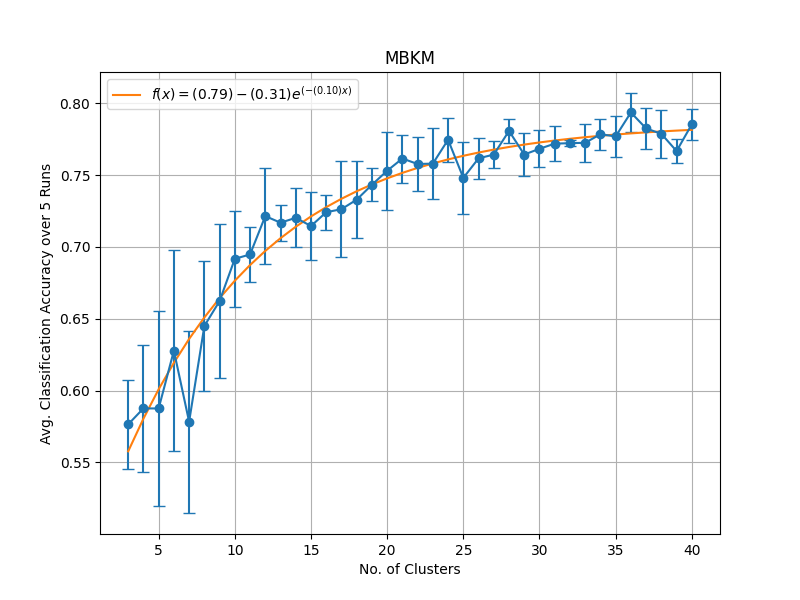

In [22]:
# Group the results by number of clusters 
acc_summary = results.groupby("n_clusters")["accuracy"]
# Calculate mean, std, and count of accuracy
acc_summary = acc_summary.agg(["mean", "std", "count"])
acc_summary = acc_summary.reset_index()
# Calculate standard error of the mean (SEM)
acc_summary["sem"] = acc_summary["std"] / np.sqrt(acc_summary["count"])
print(acc_summary)

def f_x(x, A, B, C):
    return A - B*np.exp(-C*x)

popt, pcov = curve_fit(f_x, acc_summary["n_clusters"], acc_summary["mean"], p0=[0.8, 0.5, 0.2])
a,b,c = popt

plt.close('all')

plt.figure(figsize=(8, 6))
plt.errorbar(acc_summary["n_clusters"], acc_summary["mean"], yerr=acc_summary["std"], fmt="o-", capsize=4)
plt.plot(acc_summary["n_clusters"], f_x(acc_summary["n_clusters"], *popt), label=f'$f(x) = ({a:.2f}) - ({b:.2f})e^{{(-({c:.2f})x)}}$')
plt.xlabel("No. of Clusters")
plt.ylabel(f"Avg. Classification Accuracy over {no_of_runs} Runs")
plt.grid()
plt.legend()
plt.title(f'{method}')
plt.show()

### No. of clusters vs Avg. Inertia

    n_clusters          mean           std  count           sem
0            3  1.132214e+08  2.238446e+06      5  1.001064e+06
1            4  1.090223e+08  4.342578e+06      5  1.942060e+06
2            5  1.078594e+08  3.705679e+06      5  1.657230e+06
3            6  9.892922e+07  1.049127e+07      5  4.691837e+06
4            7  9.742695e+07  1.042224e+07      5  4.660967e+06
5            8  9.293333e+07  2.222572e+07      5  9.939643e+06
6            9  8.422645e+07  1.692072e+07      5  7.567177e+06
7           10  8.004866e+07  2.247406e+07      5  1.005071e+07
8           11  8.909510e+07  1.811708e+07      5  8.102205e+06
9           12  9.401229e+07  7.492169e+06      5  3.350600e+06
10          13  5.158517e+07  3.073024e+07      5  1.374298e+07
11          14  9.241766e+07  5.766437e+06      5  2.578829e+06
12          15  3.986857e+07  1.893252e+07      5  8.466880e+06
13          16  3.472940e+07  2.589839e+07      5  1.158211e+07
14          17  5.591033e+07  3.198542e+

/tmp/ipykernel_3912414/2725636243.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


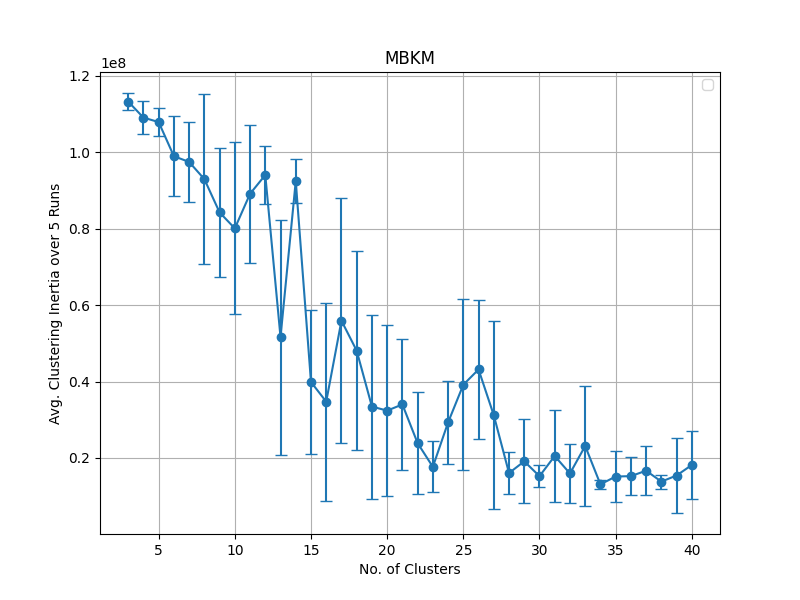

In [36]:
# Group the results by number of clusters 
inertia_summary = results.groupby("n_clusters")['inertia']
# Calculate mean, std, and count of chosen statistic
inertia_summary = inertia_summary.agg(["mean", "std", "count"])
inertia_summary = inertia_summary.reset_index()
# Calculate standard error of the mean (SEM)
inertia_summary["sem"] = inertia_summary["std"] / np.sqrt(inertia_summary["count"])
print(inertia_summary)

plt.close('all')

plt.figure(figsize=(8, 6))
plt.errorbar(inertia_summary["n_clusters"], inertia_summary["mean"], yerr=inertia_summary["std"], fmt="o-", capsize=4)
plt.xlabel("No. of Clusters")
plt.ylabel(f"Avg. Clustering Inertia over {no_of_runs} Runs")
plt.grid()
plt.legend()
plt.title(f'{method}')
plt.show()

### No. of clusters vs Avg. Silhouette Score

    n_clusters      mean       std  count       sem
0            3 -0.001947  0.083435      5  0.037313
1            4 -0.016419  0.029296      5  0.013101
2            5  0.005978  0.029791      5  0.013323
3            6  0.025565  0.017129      5  0.007660
4            7  0.039883  0.019150      5  0.008564
5            8  0.061045  0.006057      5  0.002709
6            9  0.059102  0.007197      5  0.003218
7           10  0.053204  0.015838      5  0.007083
8           11  0.068806  0.009920      5  0.004436
9           12  0.068378  0.008609      5  0.003850
10          13  0.072049  0.012106      5  0.005414
11          14  0.070461  0.004967      5  0.002221
12          15  0.079058  0.014188      5  0.006345
13          16  0.085646  0.009721      5  0.004348
14          17  0.079856  0.008424      5  0.003767
15          18  0.086842  0.003165      5  0.001415
16          19  0.089036  0.011028      5  0.004932
17          20  0.093844  0.010451      5  0.004674
18          

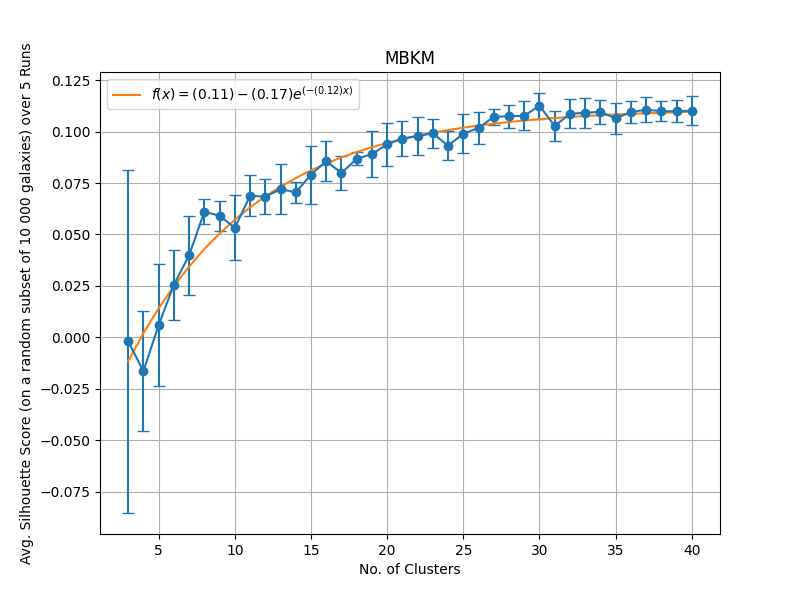

In [26]:
# Group the results by number of clusters 
sil_summary = results.groupby("n_clusters")["silhouette"]
# Calculate mean, std, and count of silhouette
sil_summary = sil_summary.agg(["mean", "std", "count"])
sil_summary = sil_summary.reset_index()
# Calculate standard error of the mean (SEM)
sil_summary["sem"] = sil_summary["std"] / np.sqrt(sil_summary["count"])
print(sil_summary)

popt, pcov = curve_fit(f_x, sil_summary["n_clusters"], sil_summary["mean"], p0=[0.1, 0.2, 0.1])
a,b,c = popt

plt.close('all')

plt.figure(figsize=(8, 6))
plt.errorbar(sil_summary["n_clusters"], sil_summary["mean"], yerr=sil_summary["std"], fmt="o-", capsize=4)
plt.plot(sil_summary["n_clusters"], f_x(sil_summary["n_clusters"], *popt), label=f'$f(x) = ({a:.2f}) - ({b:.2f})e^{{(-({c:.2f})x)}}$')
plt.xlabel("No. of Clusters")
plt.ylabel(f"Avg. Silhouette Score (on a random subset of 10 000 galaxies) over {no_of_runs} Runs")
plt.grid()
plt.legend()
plt.title(f'{method}')
plt.show()

### No. of clusters vs Avg. David-Bouldin Score

    n_clusters      mean       std  count       sem
0            3  3.129457  0.898839      5  0.401973
1            4  2.976972  0.250436      5  0.111998
2            5  2.540709  0.258450      5  0.115583
3            6  2.931319  0.266406      5  0.119140
4            7  2.621992  0.123182      5  0.055089
5            8  2.467508  0.149393      5  0.066811
6            9  2.434817  0.149795      5  0.066990
7           10  2.428064  0.101488      5  0.045387
8           11  2.313029  0.105797      5  0.047314
9           12  2.311303  0.040398      5  0.018067
10          13  2.150676  0.184042      5  0.082306
11          14  2.220364  0.161302      5  0.072137
12          15  1.999686  0.128486      5  0.057461
13          16  1.952015  0.091325      5  0.040842
14          17  1.980199  0.142656      5  0.063798
15          18  1.956451  0.073665      5  0.032944
16          19  1.851233  0.068284      5  0.030538
17          20  1.866950  0.085822      5  0.038381
18          

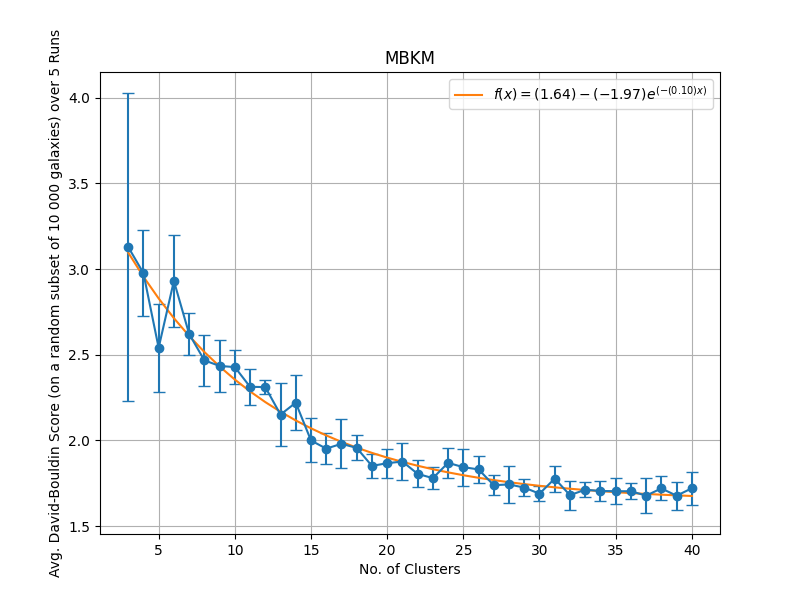

In [37]:
# Group the results by number of clusters 
david_summary = results.groupby("n_clusters")["david_bouldin"]
# Calculate mean, std, and count of silhouette
david_summary = david_summary.agg(["mean", "std", "count"])
david_summary = david_summary.reset_index()
# Calculate standard error of the mean (SEM)
david_summary["sem"] = david_summary["std"] / np.sqrt(david_summary["count"])
print(david_summary)

popt, pcov = curve_fit(f_x, david_summary["n_clusters"], david_summary["mean"], p0=[1.5, -2, 0.1])
a,b,c = popt

plt.close('all')

plt.figure(figsize=(8, 6))
plt.errorbar(david_summary["n_clusters"], david_summary["mean"], yerr=david_summary["std"], fmt="o-", capsize=4)
plt.plot(david_summary["n_clusters"], f_x(david_summary["n_clusters"], *popt), label=f'$f(x) = ({a:.2f}) - ({b:.2f})e^{{(-({c:.2f})x)}}$')
plt.xlabel("No. of Clusters")
plt.ylabel(f"Avg. David-Bouldin Score (on a random subset of 10 000 galaxies) over {no_of_runs} Runs")
plt.grid()
plt.legend()
plt.title(f'{method}')
plt.show()

## Uncertainty Analysis

In [ ]:
from projectFunctions import distance_bin_plots, confidence_bin_plots
plt.close('all')
# Plotting the Confusion Matrix
_, ax1 = plt.subplots(1,1,figsize=(8,6), constrained_layout=True)
cm = confusion_matrix(test_subset['Volunteer_Label'], test_subset['Predicted_Label'], labels=['R', 'S', 'E'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Round Elliptical', 'Spiral', 'Edge-On'], )
disp.plot(ax=ax1, colorbar=False ,cmap=plt.cm.Blues)
ax1.tick_params(axis="y", rotation=90)
plt.savefig(os.path.join('Data/Thesis Plots', f'{method}_confusion_matrix.png'), bbox_inches='tight')
plt.show()

distance_bin_plots(test_subset, xlimits=None, ylimits=None, method=method)
confidence_bin_plots(test_subset, width=1, xlimits=None, ylimits=None, method=method)

## UMAP Clustering Analysis

In [ ]:
umap = UMAP(n_components=2, random_state=20)
umap_features = umap.fit_transform(pca_features)

### Full Feature Space

#### Coloured by Cluster

In [ ]:
clusters_integers = clusters["Cluster"].astype(int)

cmap = plt.get_cmap("tab20", no_of_clusters)
norm = mcolors.BoundaryNorm(np.arange(-0.5, no_of_clusters+0.5, 1), cmap.N)

fig, ax = plt.subplots(figsize=(10, 8))

sc = plt.scatter(umap_features[:, 0], umap_features[:, 1], c=clusters_integers, cmap=cmap, s=2, norm=norm, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(no_of_clusters))
cbar.set_label('Cluster')
plt.clim(-0.5, no_of_clusters-0.5)

if method == 'MBKM':
    plt.title('Full MBKM Feature Space UMAP: Colored by Cluster')
elif method == 'BGMM':
    plt.title('Full BGMM Feature Space UMAP: Colored by Cluster')

plt.xlabel('Arbitrary Units')
plt.ylabel('Arbitrary Units')

plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Full_{method}_Feature_Space_UMAP_Colored_by_Cluster.png'), dpi=300, bbox_inches='tight')
plt.show()

#### Coloured by Type

In [ ]:
class_order = ['R', 'S', 'E']
class_to_int = {label: i for i, label in enumerate(class_order)}

type_colours = ["#9467bd", '#ffbb78', "#17becf"]
cmap_type = ListedColormap(type_colours)
norm_type = mcolors.BoundaryNorm(np.arange(-0.5, len(class_order)+0.5, 1),cmap_type.N)

type_ints = clusters['Dominant_Type'].map(class_to_int)

plt.figure(figsize=(10, 8))

sc = plt.scatter(umap_features[:,0],umap_features[:,1],c=type_ints,cmap=cmap_type,norm=norm_type,s=2, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(len(class_order)))
cbar.set_ticklabels(class_order)
cbar.set_label('Predicted Morphological Label')

if method == 'MBKM':
    plt.title('Full MBKM Feature Space UMAP: Colored by Predicted Type')
elif method == 'BGMM':
    plt.title('Full BGMM Feature Space UMAP: Colored by Predicted Type')

plt.xlabel('Arbitrary Units')
plt.ylabel('Arbitrary Units')

plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Full_{method}_Feature_Space_UMAP_Colored_by_Predicted_Type.png'), dpi=300, bbox_inches='tight')
plt.show()

#### Coloured by Uncertainty

In [ ]:
mask = ((clusters[f"Assigned_{prefix}"] < 10)   #< clusters[f"Assigned_{prefix}"].max())
        & (~clusters['Cluster'].isin(low_member_clusters)) )
        #& (~clusters['Cluster'].isin(low_percentage_clusters)) )
selected_features = umap_features[mask.to_numpy()]
selected_distances = clusters.loc[mask, f"Assigned_{prefix}"]

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
#sc = plt.scatter(umap_features[:, 0], umap_features[:, 1], c=clusters[f'Assigned_{prefix}'], cmap='cool', s=2, alpha=0.5)
sc = plt.scatter(selected_features[:, 0], selected_features[:, 1], c=selected_distances, cmap='cool', s=2, alpha=0.5)

cbar = plt.colorbar(sc)
cbar.set_label(f'Assigned {prefix}')

plt.title(f'Full {method} Feature Space UMAP: Colored by {prefix}')

plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Full_{method}_Feature_Space_UMAP_Colored_by_Assigned_{prefix}.png'), dpi=300, bbox_inches='tight')
plt.show()

### Test Set on Feature Space

In [ ]:
mask = pca_features.index.isin(test_subset.index)

#### Coloured by Cluster

In [ ]:
colors = plt.cm.tab20.colors
cmap = ListedColormap(colors[:no_of_clusters])
cluster_labels, cluster_ints = np.unique(test_subset['Cluster'], return_inverse=True)

plt.figure(figsize=(10, 8))

plt.scatter(umap_features[~mask, 0], umap_features[~mask, 1], c='lightgrey', s=2, label='Unlabelled')
sc = plt.scatter(umap_features[mask, 0], umap_features[mask, 1], c=cluster_ints, cmap=cmap, s=2, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(len(cluster_labels)))
cbar.set_label('Cluster')
cbar.set_ticks(np.arange(len(cluster_labels)))
cbar.set_ticklabels(cluster_labels)
plt.clim(-0.5, len(cluster_labels)-0.5)

if method == 'MBKM':
    plt.title('Test Set MBKM Feature Space UMAP: Colored by Cluster')
elif method == 'BGMM':
    plt.title('Test Set BGMM Feature Space UMAP: Colored by Cluster')

plt.legend()
plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Test_Set_{method}_Feature_Space_UMAP_Colored_by_Cluster.png'), dpi=300, bbox_inches='tight')
plt.show()

#### Coloured by Type

In [ ]:
type_ints = test_subset['Volunteer_Label'].map(class_to_int)

plt.figure(figsize=(10, 8))

plt.scatter(umap_features[~mask, 0], umap_features[~mask, 1], c='lightgrey', s=2, label='Unlabelled')
sc = plt.scatter(umap_features[mask, 0], umap_features[mask, 1], c=type_ints, cmap=cmap_type, norm=norm_type, s=2, alpha=0.5)

cbar = plt.colorbar(sc, ticks=np.arange(len(class_order)))
cbar.set_ticklabels(class_order)
cbar.set_label('Volunteer Label')

if method == 'MBKM':
    plt.title('Test Set MBKM Feature Space UMAP: Colored by Volunteer Label')
elif method == 'BGMM':
    plt.title('Test Set BGMM Feature Space UMAP: Colored by Volunteer Label')

plt.legend()
plt.savefig(os.path.join(data_root_dir, f'Thesis Plots/Test_Set_{method}_Feature_Space_UMAP_Colored_by_Volunteer_Label.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
correct = (test_subset['Volunteer_Label'] == test_subset['Predicted_Label']).to_numpy()

plt.figure(figsize=(8, 8))

plt.scatter(umap_features[~mask, 0],umap_features[~mask, 1],c='lightgrey',s=2)
plt.scatter(umap_features[mask][~correct, 0],umap_features[mask][~correct, 1],c='salmon',s=2,label='Incorrect', alpha=0.5)

if method == 'MBKM':
    plt.title('Test Set MBKM Feature Space UMAP: Colored by Accuracy of Predicted Label')
elif method == 'BGMM':
    plt.title('Test Set BGMM Feature Space UMAP: Colored by Accuracy of Predicted Label')
plt.xticks([])
plt.yticks([]) 
plt.legend()
plt.show()

## Interactive UMAP (Test Set on Feature Space)

In [ ]:
from IPython.display import display
%matplotlib widget

um_feats = pd.DataFrame(umap_features, index=pca_features.index, columns=['0', '1'])
um_feats = um_feats[mask]
x = um_feats['0'].values
y = um_feats['1'].values
labels = um_feats.index.to_numpy()
plt.close('all')
fig, ax = plt.subplots(figsize=(5,5))
sc = ax.scatter(x, y, c='k', alpha=0.1, s=1)

clicked = [] # keep track of selected indices

def on_click(event):
    if event.inaxes != ax:
        return
    click_x, click_y = event.xdata, event.ydata
    dist = np.hypot(x - click_x, y - click_y)
    i = np.argmin(dist)

    msg = f"Index: {labels[i]} (x={x[i]}, y={y[i]})"
    clicked.append(labels[i])

    # this makes sure it shows in Jupyter output
    display(msg)

    # mark and label point on plot
    ax.plot(x[i], y[i], 'ro', markersize=1)
    ax.annotate(labels[i], (x[i], y[i]), textcoords="offset points", xytext=(5,5), fontsize=2, color="red")
    fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()

#### Plotting Selected Galaxies

In [ ]:
plt.close('all')
%matplotlib inline
clicked = np.array(clicked)
filenames_to_find = set(clicked.astype(str) + '.png')

# collect paths of images to display
img_paths = []
for root, dirs, files in os.walk(img_dir):
    for file in files:
        if file in filenames_to_find:
            img_paths.append(os.path.join(root, file))

# display images in a grid
n_cols = 5  # number of columns in the grid
n_rows = (len(img_paths) + n_cols - 1) // n_cols  # compute rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()  # flatten in case of multiple rows

for ax, img_path in zip(axes, img_paths):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')  # hide axes
    ax.set_title(os.path.basename(img_path), fontsize=8)

# hide any unused axes
for ax in axes[len(img_paths):]:
    ax.axis('off')

plt.suptitle('Selected Galaxy Images', fontsize=16)
plt.tight_layout()
plt.show()